There exists an infinite number line, with its origin at 0 and extending towards the positive x-axis.

You are given a 2D array queries, which contains two types of queries:

    For a query of type 1, queries[i] = [1, x]. Build an obstacle at distance x from the origin. It is guaranteed that there is no obstacle at distance x when the query is asked.
    For a query of type 2, queries[i] = [2, x, sz]. Check if it is possible to place a block of size sz anywhere in the range [0, x] on the line, such that the block entirely lies in the range [0, x]. A block cannot be placed if it intersects with any obstacle, but it may touch it. Note that you do not actually place the block. Queries are separate.

Return a boolean array results, where results[i] is true if you can place the block specified in the ith query of type 2, and false otherwise.

 

Example 1:

Input: queries = [[1,2],[2,3,3],[2,3,1],[2,2,2]]

Output: [false,true,true]

Explanation:

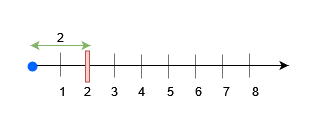

For query 0, place an obstacle at x = 2. A block of size at most 2 can be placed before x = 3.

Example 2:

Input: queries = [[1,7],[2,7,6],[1,2],[2,7,5],[2,7,6]]

Output: [true,true,false]

Explanation:

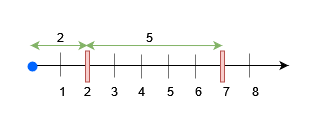

    Place an obstacle at x = 7 for query 0. A block of size at most 7 can be placed before x = 7.
    Place an obstacle at x = 2 for query 2. Now, a block of size at most 5 can be placed before x = 7, and a block of size at most 2 before x = 2.

 

Constraints:

    1 <= queries.length <= 15 * 104
    2 <= queries[i].length <= 3
    1 <= queries[i][0] <= 2
    1 <= x, sz <= min(5 * 104, 3 * queries.length)
    The input is generated such that for queries of type 1, no obstacle exists at distance x when the query is asked.
    The input is generated such that there is at least one query of type 2.


In [ ]:
class Solution:
    def getResults(self, queries: List[List[int]]) -> List[bool]:
        self.mx = 50000
        self.seg = [0] * (self.mx << 2)
        self.st = SortedList([0, self.mx])
        self.update(self.mx, self.mx, 1, 0, self.mx)
        ans = []

        for q in queries:
            if q[0] == 1:
                x = q[1]
                idx = min(len(self.st) - 1, self.st.bisect_right(x))

                r = self.st[idx]
                l = self.st[idx - 1] if idx > 0 else self.st[0]
                self.update(x, x - l, 1, 0, self.mx)
                self.update(r, r - x, 1, 0, self.mx)
                self.st.add(x)
            else:
                x, sz = q[1], q[2]
                idx = min(len(self.st) - 1, self.st.bisect_right(x))
                pre = self.st[0] if idx == 0 else self.st[idx - 1]

                max_space = max(x - pre, self.query(0, pre, 1, 0, self.mx))
                ans.append(max_space >= sz)

        return ans
    
    def __init__(self):
        self.seg = []
        self.st = SortedList()
        self.mx = 50000

    def update(self, idx: int, val: int, p: int, l: int, r: int) -> None:
        if l == r:
            self.seg[p] = val
            return

        mid = (l + r) >> 1
        if idx <= mid:
            self.update(idx, val, p << 1, l, mid)
        else:
            self.update(idx, val, p << 1 | 1, mid + 1, r)

        self.seg[p] = max(self.seg[p << 1], self.seg[p << 1 | 1])

    def query(self, L: int, R: int, p: int, l: int, r: int) -> int:
        if L <= l and r <= R:
            return self.seg[p]

        mid = (l + r) >> 1
        res = 0
        if L <= mid:
            res = max(res, self.query(L, R, p << 1, l, mid))
        if R > mid:
            res = max(res, self.query(L, R, p << 1 | 1, mid + 1, r))

        return res
